# Simulation Eigen Diagnostics — Pure-Space Smooth Sweep (local)

Amarel script
`Exercises/st_model/day/pure_space/simulation/eig_diag_sim_july_pure_space.py`
을 로컬 notebook으로 가져온 버전.

목표:
- gridded July simulation pickle 사용
- smooth `0.3`, `0.5`, `1.0` 비교
- sparse whole-domain thinning `x8`, `x4`
- geographic tile split `4x4`
- fitting은 `phi1/phi2` microergodic reparameterization 사용
  - `phi2 = 1 / range`
  - `phi1 = sigmasq * phi2`
  - `sigmasq = phi1 / phi2`
  - `range = 1 / phi2`
- `smooth=0.3`과 `smooth=1.0`은 기존 spline Matérn reference (`_build_matern_spline_coeffs`)를 사용

무거운 fitting은 자동 실행하지 않도록 `RUN_NOW = False`가 기본값이다.


In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

import sys
import time
import math
import gc
from pathlib import Path
from types import SimpleNamespace
import importlib.util

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

ROOT = Path("/Users/joonwonlee/Documents/GEMS_TCO-1")
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

REF_SCRIPT = ROOT / "Exercises/st_model/day/pure_space/simulation/eig_diag_sim_july_pure_space.py"
assert REF_SCRIPT.exists(), REF_SCRIPT

spec = importlib.util.spec_from_file_location("eig_diag_ref", REF_SCRIPT)
eig_ref = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = eig_ref
spec.loader.exec_module(eig_ref)

from GEMS_TCO.kernels_space_multiscale_050826 import _build_matern_spline_coeffs

print(f"Loaded reference: {REF_SCRIPT}")
print(f"torch={torch.__version__}, cuda_available={torch.cuda.is_available()}")


Loaded reference: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/pure_space/simulation/eig_diag_sim_july_pure_space.py
torch=2.5.1, cuda_available=False


## Configuration

이 notebook은 **2022 smooth=0.5 DGP simulation data**를 기본 입력으로 사용한다.
대용량 simulation pickle은 GitHub 제한을 피하기 위해 repo 밖의 `GEMS_DATA/simulation` 아래에 둔다.

기본 로컬 위치:

```text
/Users/joonwonlee/Documents/GEMS_DATA/simulation/july_st_circulant_realpattern_smooth0p5/2022_july_st_circulant/sim_july2022_st_circulant_gridded.pkl
```


In [2]:
RUN_NOW = True      # set True after checking INPUT_PICKLE

In [3]:
YEAR = 2022
MONTH = 7
DAYS = "1,1"          # first pass: July 1 only. Use "1,31" for full July.
HOURS = "first"       # "first", "all", or explicit list/range such as "0,3,6"

# Fit smooth sweep on the same 2022 smooth=0.5 DGP simulation data.
SMOOTHS = [0.3, 0.5, 1.0]
DGP_SMOOTH = 0.5
VARIANTS = ["nugget0"]  # change to ["nugget0", "nugget_free"] if needed

REGIONS = "tiles4x4,sparse"
TILE_Y, TILE_X = 4, 4
SPARSE_STRIDES = "8,4"

NEIGHBORS = 8
MEAN_DESIGN = "base"
LBFGS_STEPS = 8
LBFGS_EVAL = 20
TARGET_CHUNK_SIZE = 1024
MIN_POINTS = 80
MAX_POINTS = 0       # if >0, deterministic subsample per tile/sparse unit
COV_JITTER = 1e-8

DEVICE = "auto"      # "auto", "cuda", or "cpu"
EIG_DEVICE = "same"  # "same", "auto", "cuda", or "cpu"
CUDA_FALLBACK = "cpu"


DATA_ROOT = Path("/Users/joonwonlee/Documents/GEMS_DATA")

candidate_inputs = [
    DATA_ROOT / "simulation/july_st_circulant_realpattern_smooth0p5/2022_july_st_circulant/sim_july2022_st_circulant_gridded.pkl",
]
INPUT_PICKLE = next((p for p in candidate_inputs if p.exists()), None)

OUT_ROOT = ROOT / "outputs/day/local_eigen_analysis/eigdiag_sim_july2022_dgp_smooth0p5_fit_smooth_sweep_051926"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

print("INPUT_PICKLE =", INPUT_PICKLE)
if INPUT_PICKLE is None:
    print("WARNING: 2022 smooth=0.5 gridded simulation pickle not found locally. Set INPUT_PICKLE manually before RUN_NOW=True.")
print("OUT_ROOT =", OUT_ROOT)


INPUT_PICKLE = /Users/joonwonlee/Documents/GEMS_DATA/simulation/july_st_circulant_realpattern_smooth0p5/2022_july_st_circulant/sim_july2022_st_circulant_gridded.pkl
OUT_ROOT = /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/local_eigen_analysis/eigdiag_sim_july2022_dgp_smooth0p5_fit_smooth_sweep_051926


## General Matérn covariance for eigen decomposition

The reference script fits `smooth=0.3/1.0` correctly through the pure-space iso
Vecchia wrapper, but its explicit covariance builder was originally restricted
to half-integer smooth values.  For this notebook the eigen step uses the same
spline reference used in the model code, so `0.3`, `0.5`, and `1.0` share the
same fitting/eigen diagnostic pipeline.


In [4]:
_SPLINE_TENSOR_CACHE = {}

def smooth_tag(smooth):
    return str(float(smooth)).rstrip("0").rstrip(".").replace(".", "p")


def get_fit_device(device_arg=DEVICE, fallback=CUDA_FALLBACK):
    return eig_ref.select_device(device_arg, fallback)


def get_eig_device(eig_arg, fit_device, fallback=CUDA_FALLBACK):
    return eig_ref.select_eig_device(eig_arg, fit_device, fallback)


def _spline_tensors_for_smooth(smooth, device):
    key = (round(float(smooth), 8), str(device))
    if key in _SPLINE_TENSOR_CACHE:
        return _SPLINE_TENSOR_CACHE[key]
    coeffs = _build_matern_spline_coeffs(float(smooth))
    tensors = {
        name: torch.tensor(arr, dtype=torch.float64, device=device)
        for name, arr in coeffs.items()
        if name != "r_max"
    }
    tensors["r_max"] = float(coeffs["r_max"])
    _SPLINE_TENSOR_CACHE[key] = tensors
    return tensors


def matern_corr_torch(r, smooth):
    smooth = float(smooth)
    if smooth == 0.5:
        return torch.exp(-r)
    if smooth == 1.5:
        return (1.0 + r) * torch.exp(-r)
    if smooth <= 0.0:
        raise ValueError(f"smooth must be positive, got {smooth}")
    sp = _spline_tensors_for_smooth(smooth, r.device)
    r_c = r.clamp(0.0, sp["r_max"])
    orig_shape = r_c.shape
    r_flat = r_c.reshape(-1)
    idx = torch.searchsorted(sp["knots"], r_flat, right=True) - 1
    idx = idx.clamp(0, sp["knots"].numel() - 2)
    dx = r_flat - sp["knots"][idx]
    vals = sp["a"][idx] + dx * (sp["b"][idx] + dx * (sp["c"][idx] + dx * sp["d"][idx]))
    return vals.reshape(orig_shape).clamp_min(0.0)


def fitted_covariance_any_smooth(coords, est, smooth, eig_device, jitter):
    x = torch.as_tensor(coords, device=eig_device, dtype=torch.float64)
    r = torch.cdist(x, x) / max(float(est["range"]), eig_ref.EPS)
    corr = matern_corr_torch(r, smooth)
    cov = float(est["sigmasq"]) * corr
    diag_add = max(float(est.get("nugget", 0.0)), 0.0) + max(float(jitter), 0.0)
    cov.diagonal().add_(diag_add)
    return cov


In [5]:
def eigen_diagnostic_any_smooth(z, coords, est, smooth, mean_design, args, eig_device):
    n = int(len(z))
    m_np = eig_ref.design_matrix_np(coords, mean_design)
    p = int(np.linalg.matrix_rank(m_np))
    if p >= n:
        raise ValueError(f"Mean design rank {p} is not smaller than n={n}")

    z_t = torch.as_tensor(z, device=eig_device, dtype=torch.float64)
    m_t = torch.as_tensor(m_np, device=eig_device, dtype=torch.float64)
    q, _ = torch.linalg.qr(m_t, mode="reduced")
    rz = z_t - q @ (q.T @ z_t)

    sigma = fitted_covariance_any_smooth(coords, est, smooth, eig_device, args.cov_jitter)
    a = sigma - q @ (q.T @ sigma)
    k_mat = a - (a @ q) @ q.T
    k_mat = 0.5 * (k_mat + k_mat.T)

    evals, evecs = torch.linalg.eigh(k_mat)
    max_eval = torch.clamp(evals.max(), min=torch.as_tensor(eig_ref.EPS, device=eig_device, dtype=torch.float64))
    threshold = max(float(args.eigenvalue_atol), float(args.eigenvalue_rtol) * float(max_eval.detach().cpu().item()))
    keep = evals > threshold
    evals = evals[keep]
    evecs = evecs[:, keep]
    if evals.numel() == 0:
        raise ValueError("No positive projected covariance eigenvalues survived the threshold.")

    order = torch.argsort(evals, descending=True)
    evals = evals[order]
    evecs = evecs[:, order]
    scores = (evecs.T @ rz) / torch.sqrt(evals)
    y2 = scores.pow(2)
    csum = torch.cumsum(y2, dim=0)

    y2_np = y2.detach().cpu().numpy()
    csum_np = csum.detach().cpu().numpy()
    evals_np = evals.detach().cpu().numpy()
    m = int(len(y2_np))
    index = np.arange(1, m + 1, dtype=np.int64)
    width = float(args.brown_bridge_q) * math.sqrt(2.0 * m)
    bridge_d = float(np.max(np.abs(csum_np - index)) / math.sqrt(2.0 * m))
    curve = pd.DataFrame({
        "index": index,
        "eigenvalue": evals_np,
        "y2": y2_np,
        "cumsum_y2": csum_np,
        "expected": index.astype(float),
        "band_lower": index.astype(float) - width,
        "band_upper": index.astype(float) + width,
    })
    summary = {
        "n_obs": n,
        "mean_rank": p,
        "n_eigen": m,
        "eigen_threshold": threshold,
        "min_kept_eigen": float(np.min(evals_np)),
        "max_kept_eigen": float(np.max(evals_np)),
        "sum_y2": float(csum_np[-1]),
        "mean_y2": float(np.mean(y2_np)),
        "max_abs_bridge_scaled": bridge_d,
        "brown_bridge_pvalue_approx": eig_ref.kolmogorov_bridge_sf(bridge_d),
        "brown_bridge_width": width,
    }
    del sigma, a, k_mat, evals, evecs, scores, y2, csum, q, rz, z_t, m_t
    return curve, summary


## Runner

This runner reuses the reference script's data parsing, gridding, x8/x4 thinning,
4x4 tiling, Vecchia precompute, and `phi1/phi2` fitting classes.  Only the
explicit eigen covariance builder is swapped to the any-smooth spline version.


In [6]:
def make_args(smooth):
    return SimpleNamespace(
        input=str(INPUT_PICKLE),
        output_root=str(OUT_ROOT),
        year=YEAR,
        month=MONTH,
        days=DAYS,
        hours=HOURS,
        smooth=float(smooth),
        regions=REGIONS,
        tile_y=TILE_Y,
        tile_x=TILE_X,
        sparse_strides=SPARSE_STRIDES,
        variants=','.join(VARIANTS),
        neighbors=NEIGHBORS,
        mean_design=MEAN_DESIGN,
        x_col="Longitude",
        y_col="Latitude",
        value_col="ColumnAmountO3",
        device=DEVICE,
        eig_device=EIG_DEVICE,
        cuda_fallback=CUDA_FALLBACK,
        target_chunk_size=TARGET_CHUNK_SIZE,
        lbfgs_steps=LBFGS_STEPS,
        lbfgs_eval=LBFGS_EVAL,
        sigmasq_init=10.0,
        range_init=0.2,
        nugget_init=1.0,
        min_points=MIN_POINTS,
        max_points=MAX_POINTS,
        cov_jitter=COV_JITTER,
        eigenvalue_rtol=1e-10,
        eigenvalue_atol=1e-12,
        brown_bridge_q=eig_ref.BROWN_BRIDGE_Q95,
        save_curves=False,
        skip_existing=True,
    )


def run_eigen_smooth_sweep():
    if INPUT_PICKLE is None:
        raise FileNotFoundError("Set INPUT_PICKLE to the gridded simulation pickle before running.")

    fit_device = get_fit_device(DEVICE, CUDA_FALLBACK)
    eig_device = get_eig_device(EIG_DEVICE, fit_device, CUDA_FALLBACK)
    print(f"fit_device={fit_device}, eig_device={eig_device}")

    hours = eig_ref.load_ordered_hours(Path(INPUT_PICKLE), YEAR, MONTH)
    tmpl = eig_ref.build_grid_template(hours[0][2], "Latitude", "Longitude")
    selected = eig_ref.select_hours(hours, eig_ref.parse_int_list_or_range(DAYS), eig_ref.parse_hours(HOURS))
    if not selected:
        raise ValueError("No selected hours. Check DAYS/HOURS.")
    print(f"grid={len(tmpl.lat_vals)}x{len(tmpl.lon_vals)}, selected_hours={len(selected)}")

    all_fit_rows = []
    all_summary_rows = []

    for smooth in SMOOTHS:
        args = make_args(smooth)
        out_root = OUT_ROOT / f"nu{smooth_tag(smooth)}"
        out_root.mkdir(parents=True, exist_ok=True)
        eig_ref.write_math_notes(out_root)
        print("\n" + "=" * 78)
        print(f"smooth={smooth} -> {out_root}")
        print("=" * 78)

        for ts, key, df in selected:
            day_label = f"{YEAR}{MONTH:02d}{ts.day:02d}"
            hour_label = f"h{ts.hour:02d}{ts.minute:02d}"
            hour_dir = out_root / f"{day_label}_{hour_label}"
            hour_dir.mkdir(parents=True, exist_ok=True)
            print(f"\n[{day_label} {hour_label}] key={key}")

            tensor_full = eig_ref.hour_tensor(df, tmpl, "Latitude", "Longitude", "ColumnAmountO3", fit_device)
            units = eig_ref.build_units(tensor_full, tmpl, args)
            overview_curves = {}

            for unit in units:
                unit_tensor = eig_ref.maybe_subsample_valid(unit.tensor, args.max_points)
                n_valid = eig_ref.count_valid(unit_tensor)
                if n_valid < max(int(args.min_points), int(args.neighbors) + 2):
                    print(f"  {unit.name}: too few valid points ({n_valid}), skip")
                    continue
                fit_tensor, fit_coords, z = eig_ref.valid_tensor_view(unit_tensor)
                print(f"  {unit.name}: n={n_valid}")

                for variant in VARIANTS:
                    png_path = hour_dir / f"{variant}_{unit.name}_eigdiag.png"
                    if args.skip_existing and png_path.exists():
                        print(f"    {variant}: plot exists, skip")
                        continue

                    t0 = time.time()
                    est, loss = eig_ref.fit_variant(variant, smooth, fit_tensor, fit_coords, args, fit_device)
                    fit_seconds = time.time() - t0

                    t1 = time.time()
                    curve, summary = eigen_diagnostic_any_smooth(
                        z, fit_coords, est, smooth, args.mean_design, args, eig_device
                    )
                    eig_seconds = time.time() - t1

                    title = (
                        f"{day_label} {hour_label}, {variant}, {unit.label}\n"
                        f"nu={smooth}, n={summary['n_obs']}, m={summary['n_eigen']}, "
                        f"D={summary['max_abs_bridge_scaled']:.3f}, "
                        f"p~{summary['brown_bridge_pvalue_approx']:.3g}"
                    )
                    eig_ref.plot_eigen_curve(curve, title, png_path)

                    row_base = {
                        "day": day_label,
                        "hour": ts.hour,
                        "minute": ts.minute,
                        "hour_key": key,
                        "family": unit.family,
                        "unit": unit.name,
                        "unit_label": unit.label,
                        "variant": variant,
                        "smooth": float(smooth),
                        "loss": loss,
                        "fit_seconds": fit_seconds,
                        "eig_seconds": eig_seconds,
                        **est,
                    }
                    all_fit_rows.append(row_base)
                    all_summary_rows.append({**row_base, **summary})

                    if unit.family == "tiles4x4":
                        overview_curves.setdefault((variant, unit.family), []).append(
                            (unit.name.replace("_of_", "\nof "), curve)
                        )

                    print(
                        f"    {variant}: sigmasq={est['sigmasq']:.4g}, "
                        f"range={est['range']:.4g}, nugget={est['nugget']:.4g}, "
                        f"D={summary['max_abs_bridge_scaled']:.3f}, "
                        f"p~{summary['brown_bridge_pvalue_approx']:.3g}, "
                        f"fit={fit_seconds:.1f}s eig={eig_seconds:.1f}s"
                    )

                    gc.collect()
                    if fit_device.type == "cuda" or eig_device.type == "cuda":
                        torch.cuda.empty_cache()

            for (variant, family), curves in overview_curves.items():
                out_path = hour_dir / f"{variant}_{family}_overview.png"
                eig_ref.plot_tile_overview(curves, f"{day_label} {hour_label}, {variant}, {family}, nu={smooth}", out_path)
                print(f"  saved overview {out_path.name}")

            if all_fit_rows:
                pd.DataFrame(all_fit_rows).round(eig_ref.ROUND_DECIMALS).to_csv(
                    OUT_ROOT / "eigen_fit_rows_all_smooths.csv", index=False, float_format="%.6f"
                )
            if all_summary_rows:
                pd.DataFrame(all_summary_rows).round(eig_ref.ROUND_DECIMALS).to_csv(
                    OUT_ROOT / "eigen_diagnostic_summary_all_smooths.csv", index=False, float_format="%.6f"
                )

    fit_df = pd.DataFrame(all_fit_rows)
    summary_df = pd.DataFrame(all_summary_rows)
    return fit_df, summary_df


## Run

Set `RUN_NOW = True` in the configuration cell after confirming `INPUT_PICKLE`.
For the first local pass, keep `YEAR=2022`, `DAYS="1,1"`, and `HOURS="first"`.


In [7]:
if RUN_NOW:
    fit_df, summary_df = run_eigen_smooth_sweep()
    display(summary_df.sort_values(["smooth", "family", "unit"]).head())
else:
    print("RUN_NOW is False. Set RUN_NOW=True after INPUT_PICKLE is set.")


CUDA not available; using CPU.
fit_device=cpu, eig_device=cpu
grid=114x159, selected_hours=1

smooth=0.3 -> /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/local_eigen_analysis/eigdiag_sim_july2022_dgp_smooth0p5_fit_smooth_sweep_051926/nu0p3

[20220701 h0053] key=y22m07day01_hm00:53
  tile_r1c1_of_4x4: n=1092
Pre-computing HybridSpaceVecchia [A=8]... Done in 0.0s. tails=1092, m mean/med/max=8.0/8/8
--- Starting Pure-Space Vecchia L-BFGS ---
--- Step 1/8 / Loss: 1.188183 / Max Grad: 5.77e-07 ---
Converged: max_grad 5.77e-07 < 1.00e-05
Final Pure-Space Params: {'sigmasq': 8.77151094789656, 'range': 0.19536874023124542, 'nugget': 0.0}
    nugget0: sigmasq=8.772, range=0.1954, nugget=0, D=0.709, p~0.697, fit=0.7s eig=0.1s
  tile_r1c2_of_4x4: n=1119
Pre-computing HybridSpaceVecchia [A=8]... Done in 0.0s. tails=1119, m mean/med/max=8.0/8/8
--- Starting Pure-Space Vecchia L-BFGS ---
--- Step 1/8 / Loss: 1.161486 / Max Grad: 8.68e-07 ---
Converged: max_grad 8.68e-07 < 1.00e-05
Final Pure-Sp

,day,hour,minute,hour_key,family,unit,unit_label,variant,smooth,loss,...,mean_rank,n_eigen,eigen_threshold,min_kept_eigen,max_kept_eigen,sum_y2,mean_y2,max_abs_bridge_scaled,brown_bridge_pvalue_approx,brown_bridge_width
17,20220701,0,53,y22m07day01_hm00:53,sparse,x4,whole domain x4,nugget0,0.3,1.578367,...,2,1157,6.980747e-09,5.166178,69.807469,1160.977494,1.003438,0.929598,0.353181,65.330188
16,20220701,0,53,y22m07day01_hm00:53,sparse,x8,whole domain x8,nugget0,0.3,1.661671,...,2,298,1.512367e-09,8.346095,15.123669,300.070833,1.006949,0.537632,0.934691,33.155483
0,20220701,0,53,y22m07day01_hm00:53,tiles4x4,tile_r1c1_of_4x4,"tile row 1/4, col 1/4",nugget0,0.3,1.188183,...,2,1090,4.460328e-08,2.021705,446.032773,1092.139848,1.001963,0.708815,0.696516,63.410398
1,20220701,0,53,y22m07day01_hm00:53,tiles4x4,tile_r1c2_of_4x4,"tile row 1/4, col 2/4",nugget0,0.3,1.161486,...,2,1117,5.445558e-08,1.888376,544.555826,1116.647274,0.999684,0.773785,0.587321,64.190952
2,20220701,0,53,y22m07day01_hm00:53,tiles4x4,tile_r1c3_of_4x4,"tile row 1/4, col 3/4",nugget0,0.3,1.167435,...,2,1118,9.759644e-08,1.890242,975.964418,1116.191496,0.998382,1.095913,0.180930,64.219679


## Summary plots after running


In [8]:
summary_path = OUT_ROOT / "eigen_diagnostic_summary_all_smooths.csv"
if summary_path.exists():
    summary_df = pd.read_csv(summary_path)
    display(summary_df.head())

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for family, sub in summary_df.groupby("family"):
        by = sub.groupby("smooth")["max_abs_bridge_scaled"].median()
        axes[0].plot(by.index, by.values, "o-", label=family)
    axes[0].set_title("Median bridge statistic by smooth")
    axes[0].set_xlabel("smooth")
    axes[0].set_ylabel("median D")
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    for family, sub in summary_df.groupby("family"):
        by = sub.groupby("smooth")["fit_seconds"].median()
        axes[1].plot(by.index, by.values, "o-", label=family)
    axes[1].set_title("Median fit seconds by smooth")
    axes[1].set_xlabel("smooth")
    axes[1].set_ylabel("seconds")
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    plt.tight_layout()
    fig.savefig(OUT_ROOT / "smooth_sweep_summary_051926.png", dpi=160, bbox_inches="tight")
    plt.show()
else:
    print(f"No summary yet: {summary_path}")


,day,hour,minute,hour_key,family,unit,unit_label,variant,smooth,loss,...,mean_rank,n_eigen,eigen_threshold,min_kept_eigen,max_kept_eigen,sum_y2,mean_y2,max_abs_bridge_scaled,brown_bridge_pvalue_approx,brown_bridge_width
0,20220701,0,53,y22m07day01_hm00:53,tiles4x4,tile_r1c1_of_4x4,"tile row 1/4, col 1/4",nugget0,0.3,1.188183,...,2,1090,0.0,2.021705,446.032773,1092.139848,1.001963,0.708815,0.696516,63.410398
1,20220701,0,53,y22m07day01_hm00:53,tiles4x4,tile_r1c2_of_4x4,"tile row 1/4, col 2/4",nugget0,0.3,1.161486,...,2,1117,0.0,1.888376,544.555826,1116.647274,0.999684,0.773785,0.587321,64.190952
2,20220701,0,53,y22m07day01_hm00:53,tiles4x4,tile_r1c3_of_4x4,"tile row 1/4, col 3/4",nugget0,0.3,1.167435,...,2,1118,0.0,1.890242,975.964418,1116.191496,0.998382,1.095913,0.180930,64.219679
3,20220701,0,53,y22m07day01_hm00:53,tiles4x4,tile_r1c4_of_4x4,"tile row 1/4, col 4/4",nugget0,0.3,1.162753,...,2,1114,0.0,1.857338,1307.311901,1115.209390,1.001086,0.918761,0.367353,64.104693
4,20220701,0,53,y22m07day01_hm00:53,tiles4x4,tile_r2c1_of_4x4,"tile row 2/4, col 1/4",nugget0,0.3,1.143132,...,2,1128,0.0,1.827997,323.594811,1129.790248,1.001587,0.843231,0.475660,64.506248


/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykernel_80973/2443388675.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Eigen Plot Gallery

저장된 eigen diagnostic PNG를 notebook 안에서 바로 확인한다. `RUN_NOW=True`로 fitting을 돌린 뒤 이 셀을 실행하면 `tiles4x4` overview와 `x4/x8` sparse plot이 표시된다.


### tiles4x4 overview (3 found)

**outputs/day/local_eigen_analysis/eigdiag_sim_july2022_dgp_smooth0p5_fit_smooth_sweep_051926/nu0p3/20220701_h0053/nugget0_tiles4x4_overview.png**

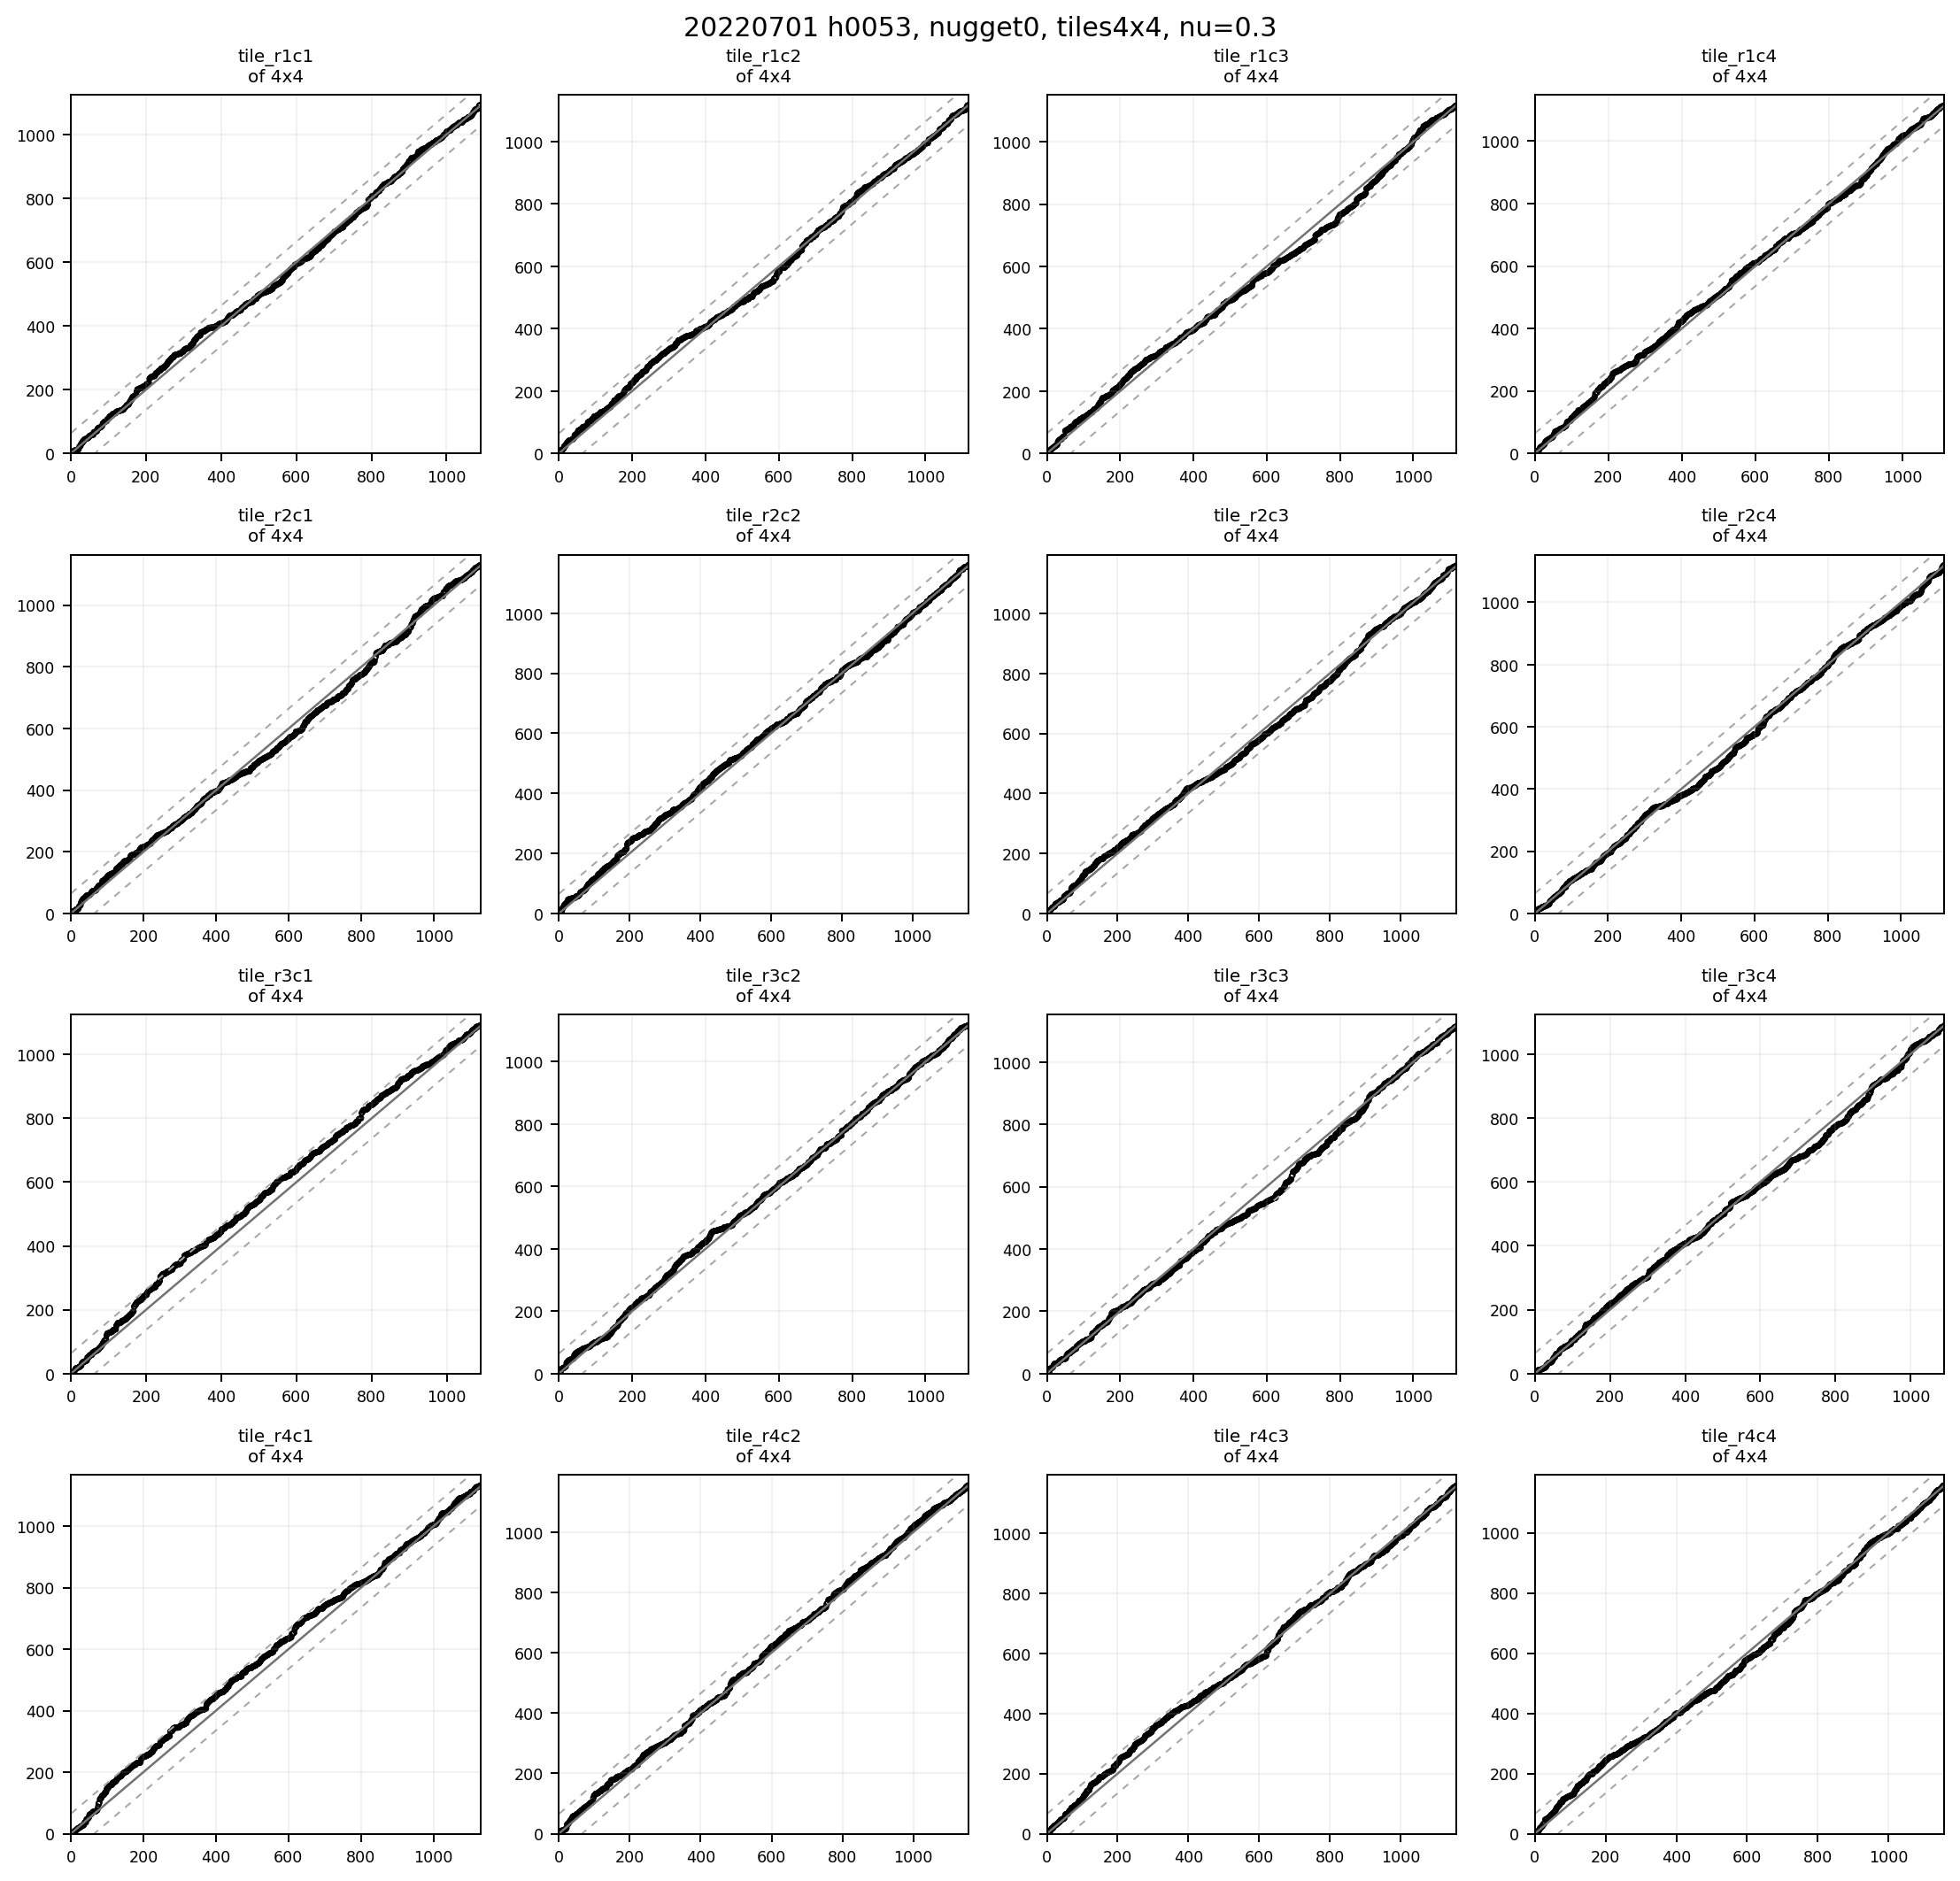

**outputs/day/local_eigen_analysis/eigdiag_sim_july2022_dgp_smooth0p5_fit_smooth_sweep_051926/nu0p5/20220701_h0053/nugget0_tiles4x4_overview.png**

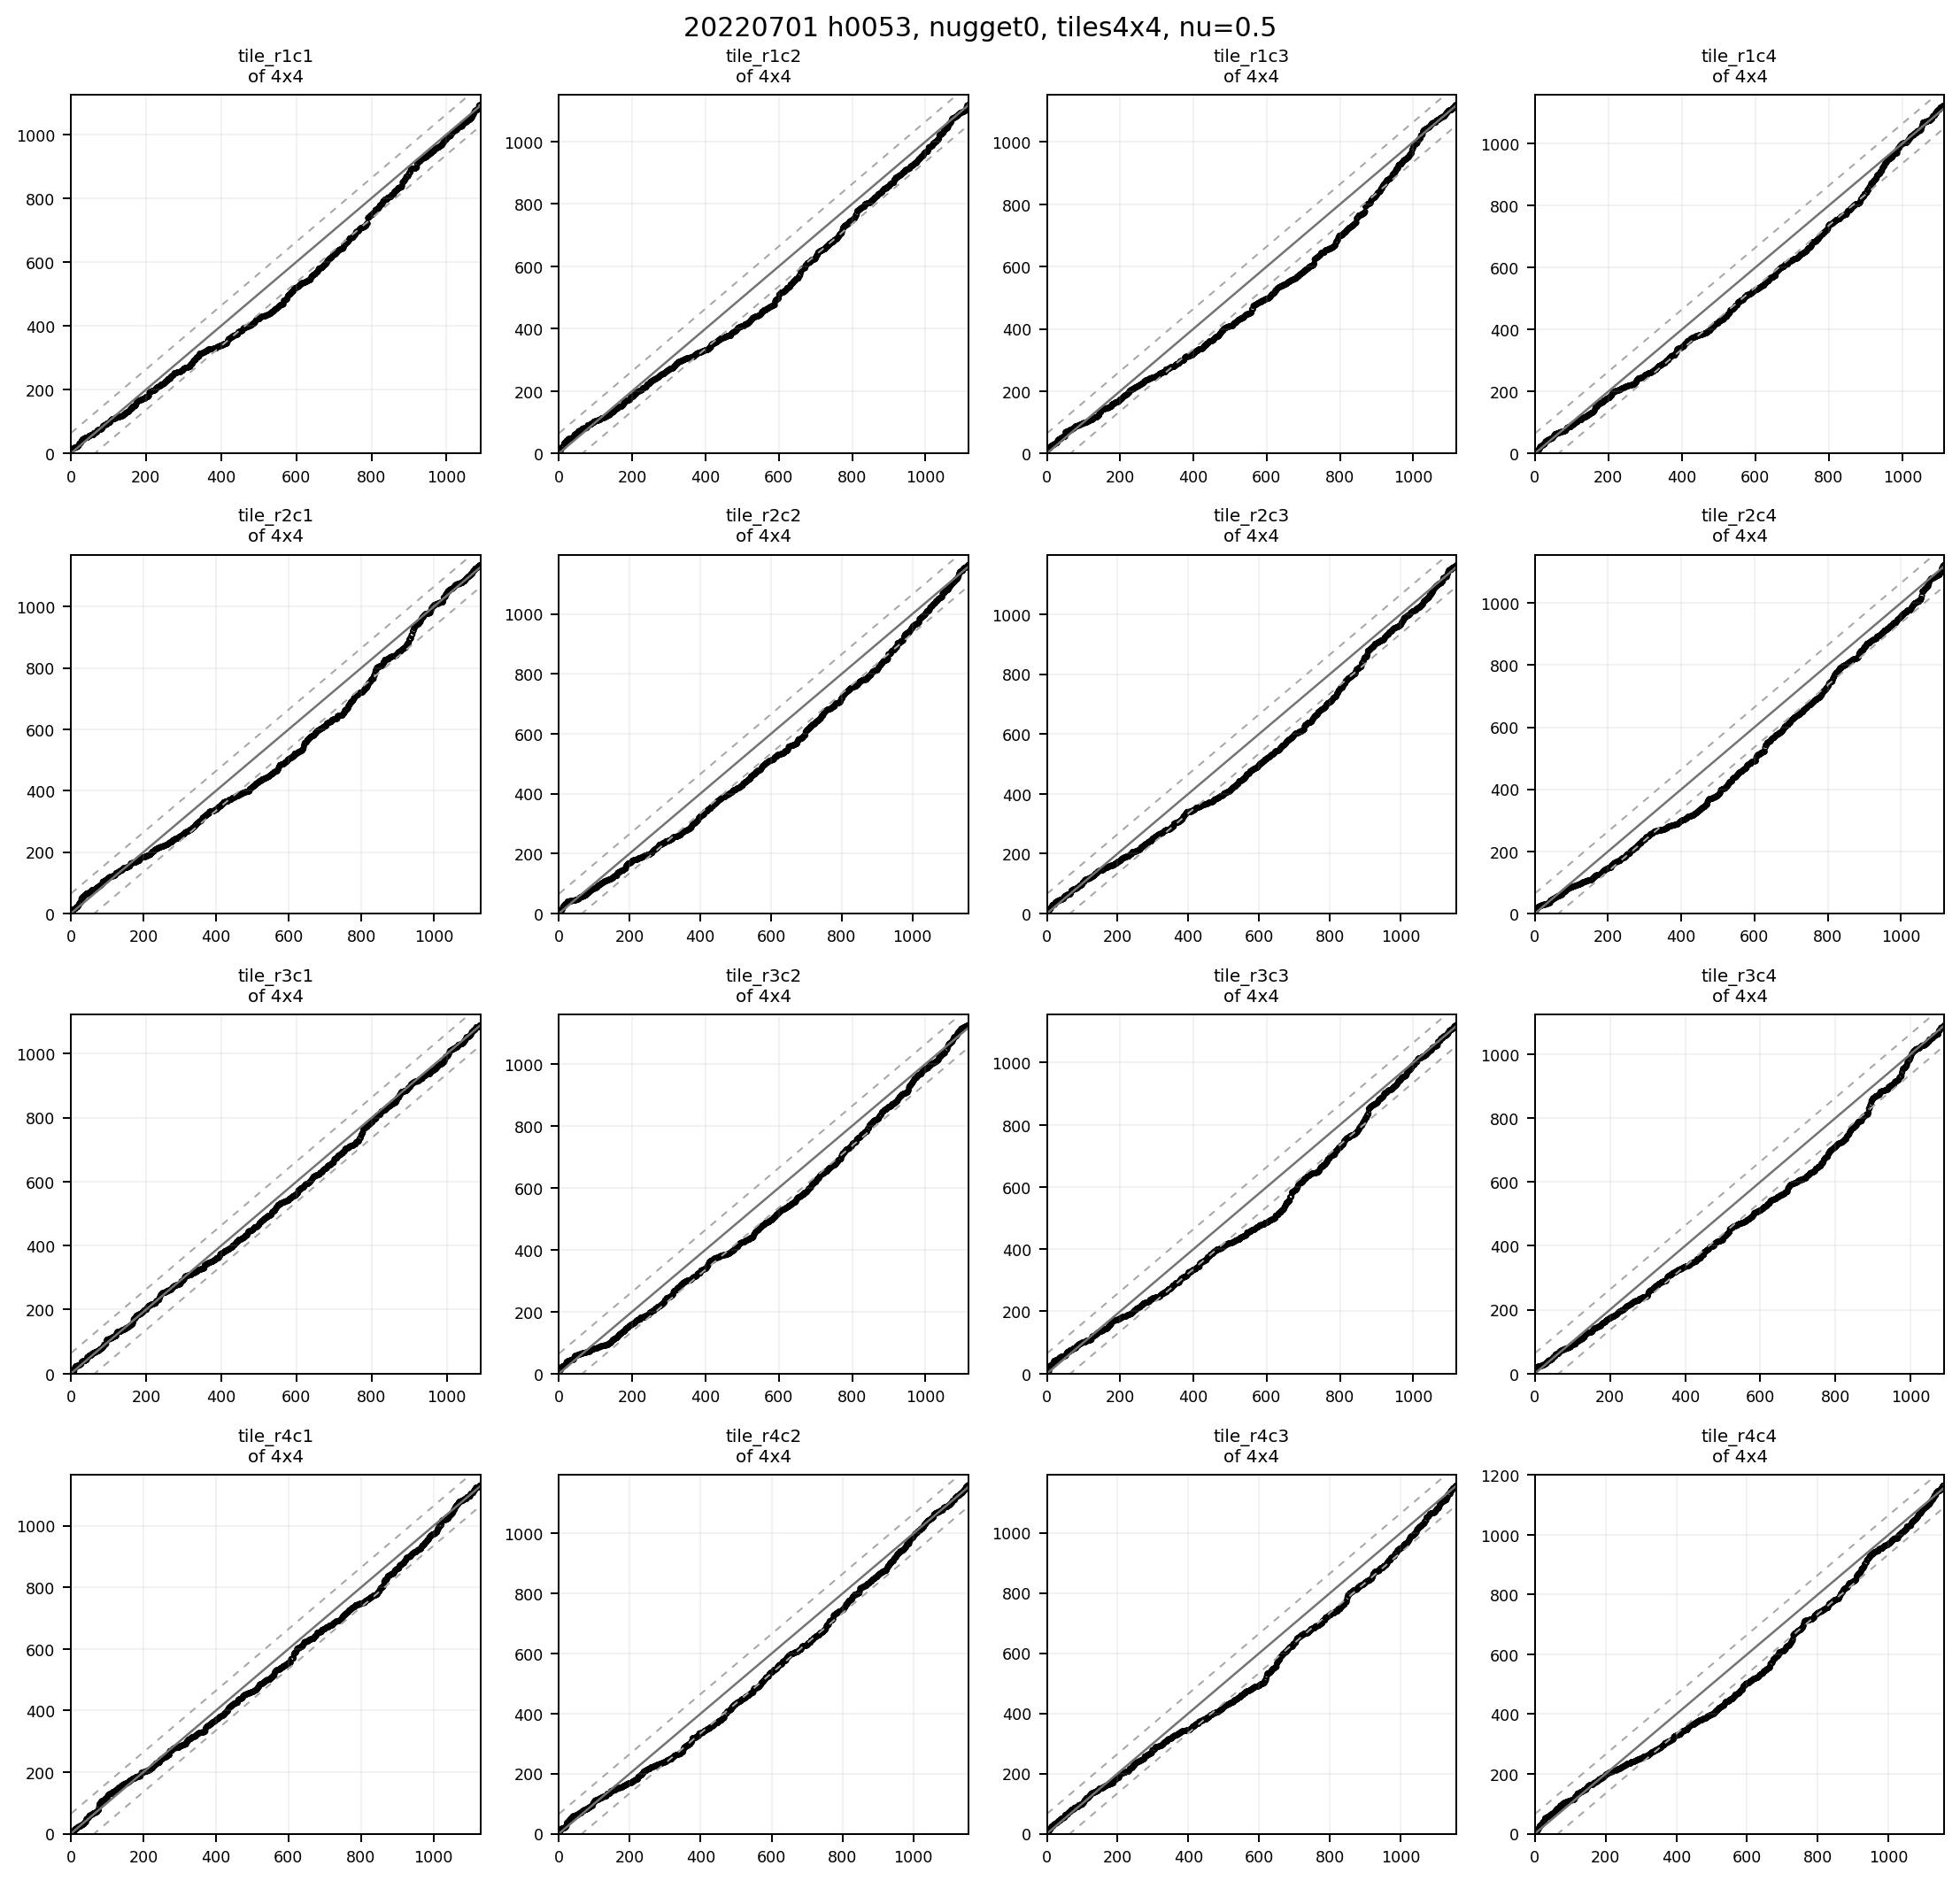

**outputs/day/local_eigen_analysis/eigdiag_sim_july2022_dgp_smooth0p5_fit_smooth_sweep_051926/nu1/20220701_h0053/nugget0_tiles4x4_overview.png**

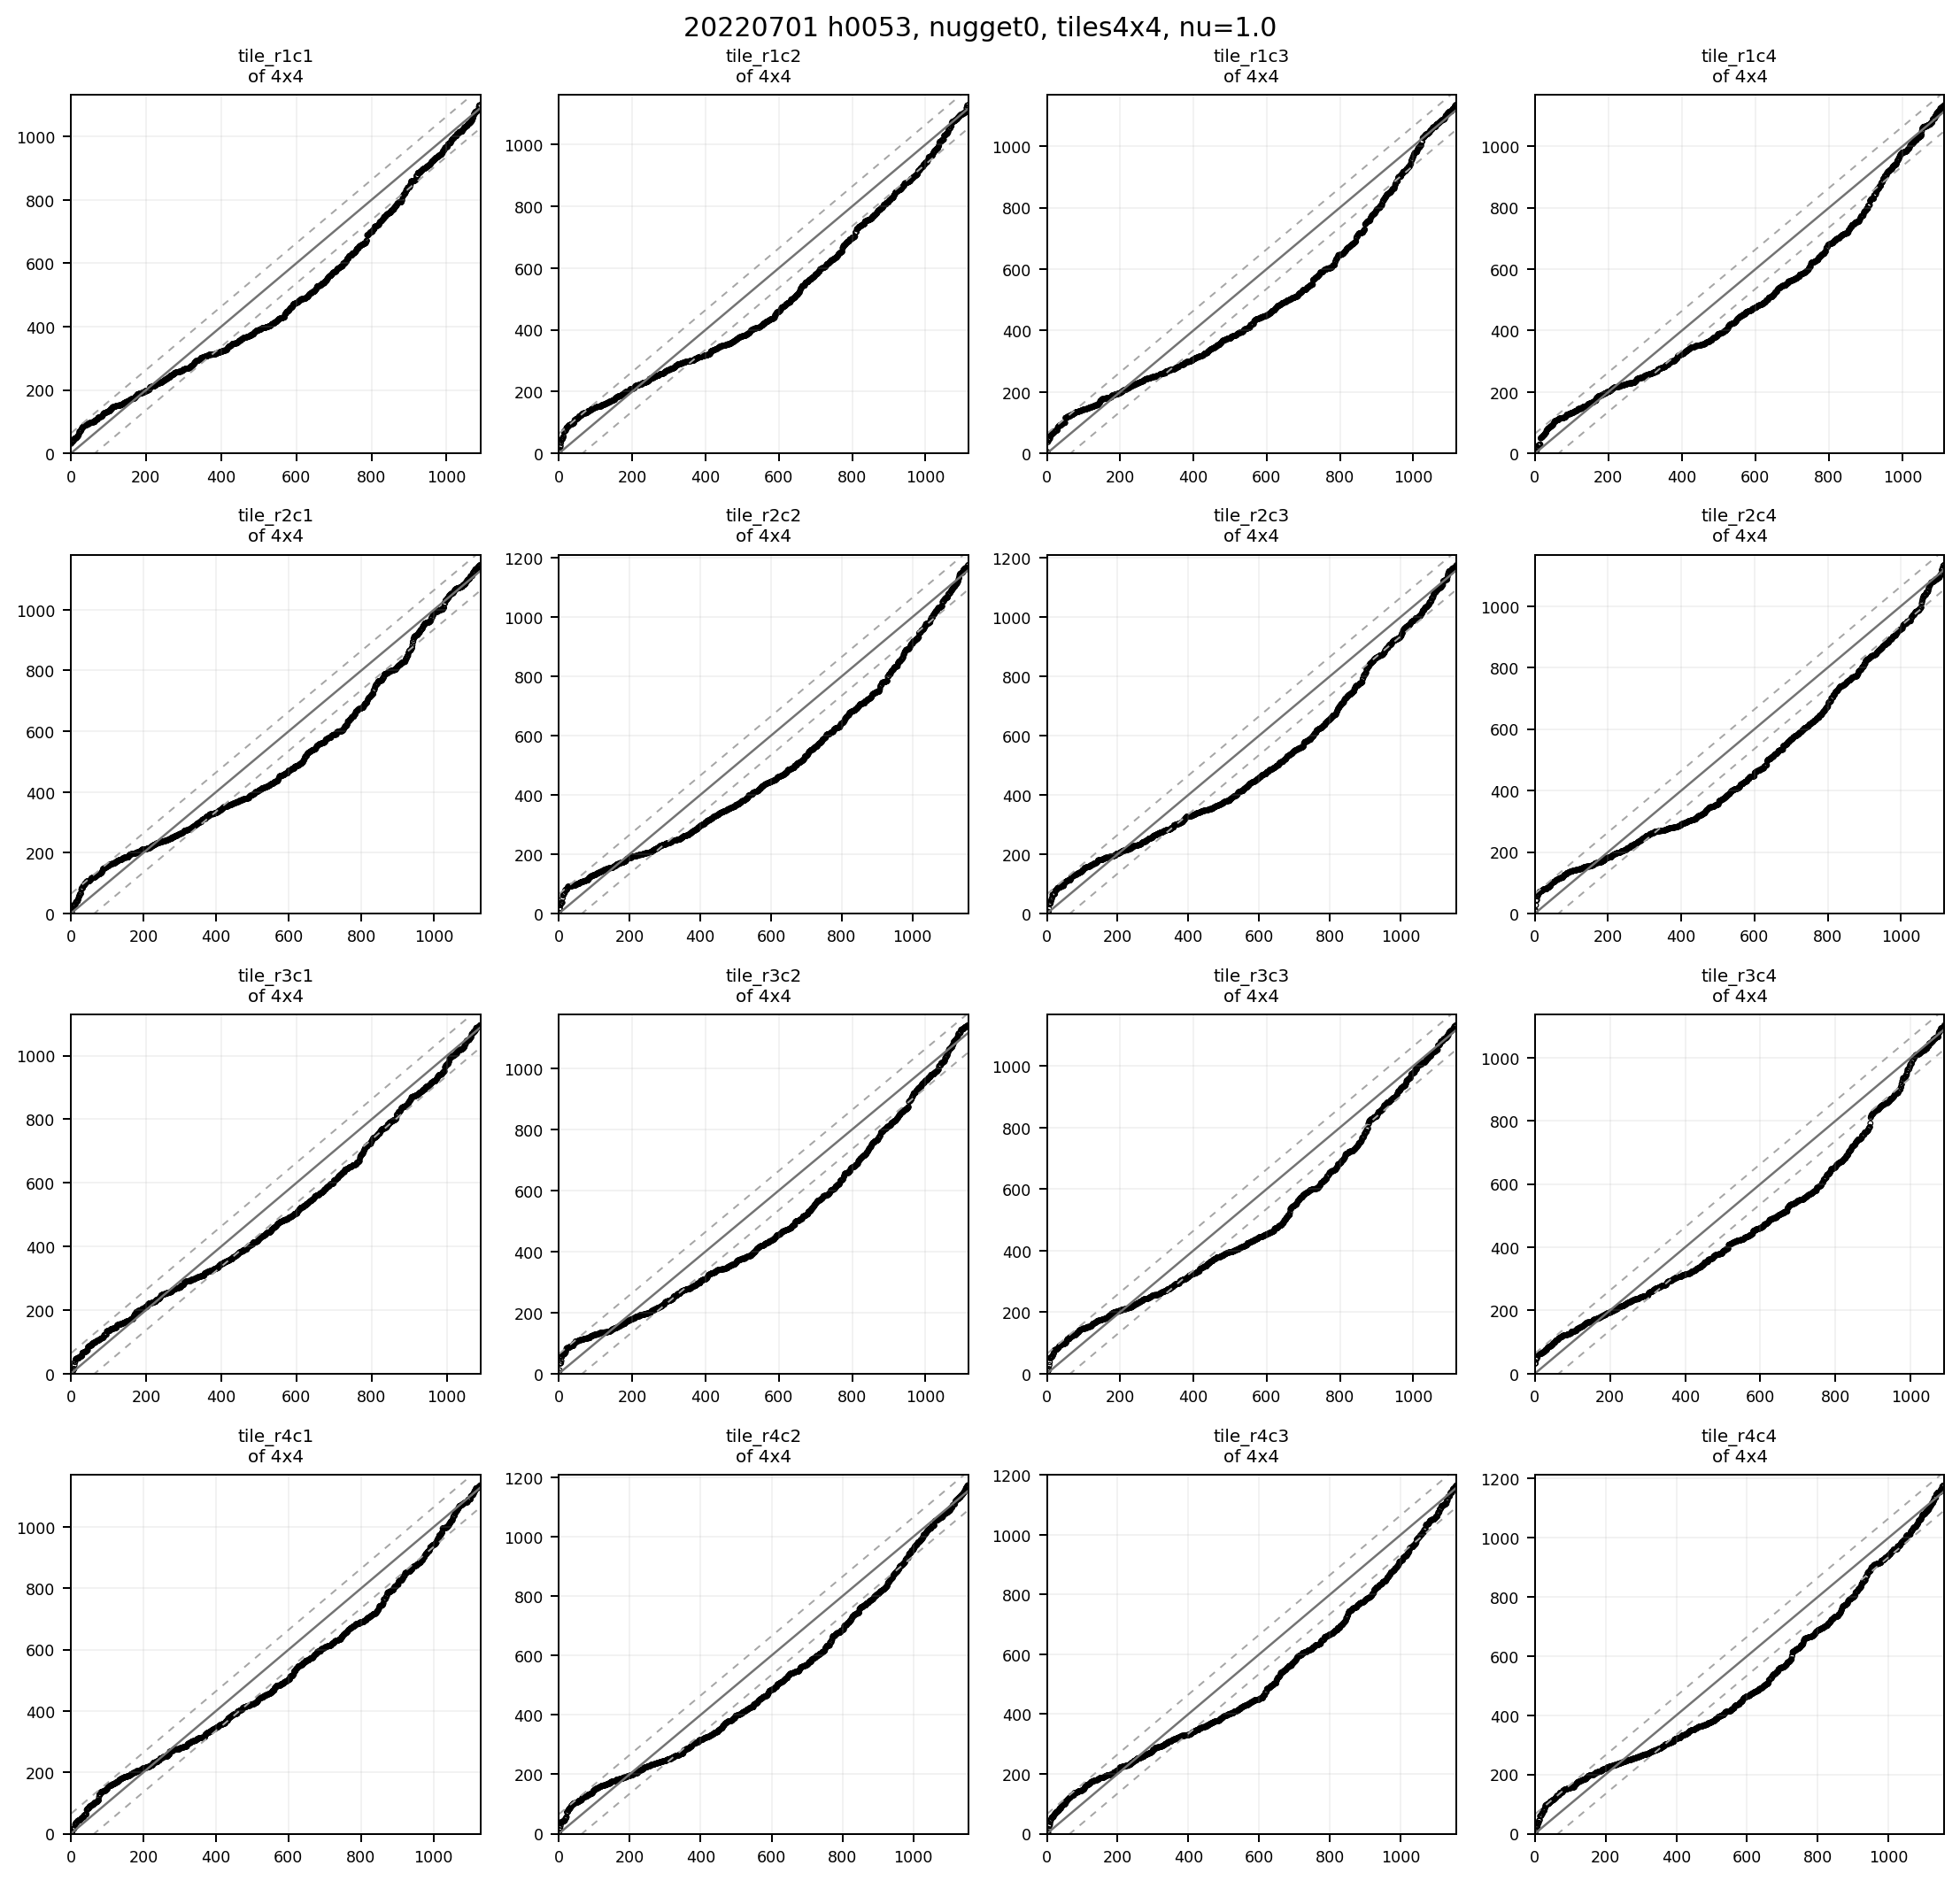

### sparse x4 (3 found)

**outputs/day/local_eigen_analysis/eigdiag_sim_july2022_dgp_smooth0p5_fit_smooth_sweep_051926/nu0p3/20220701_h0053/nugget0_x4_eigdiag.png**

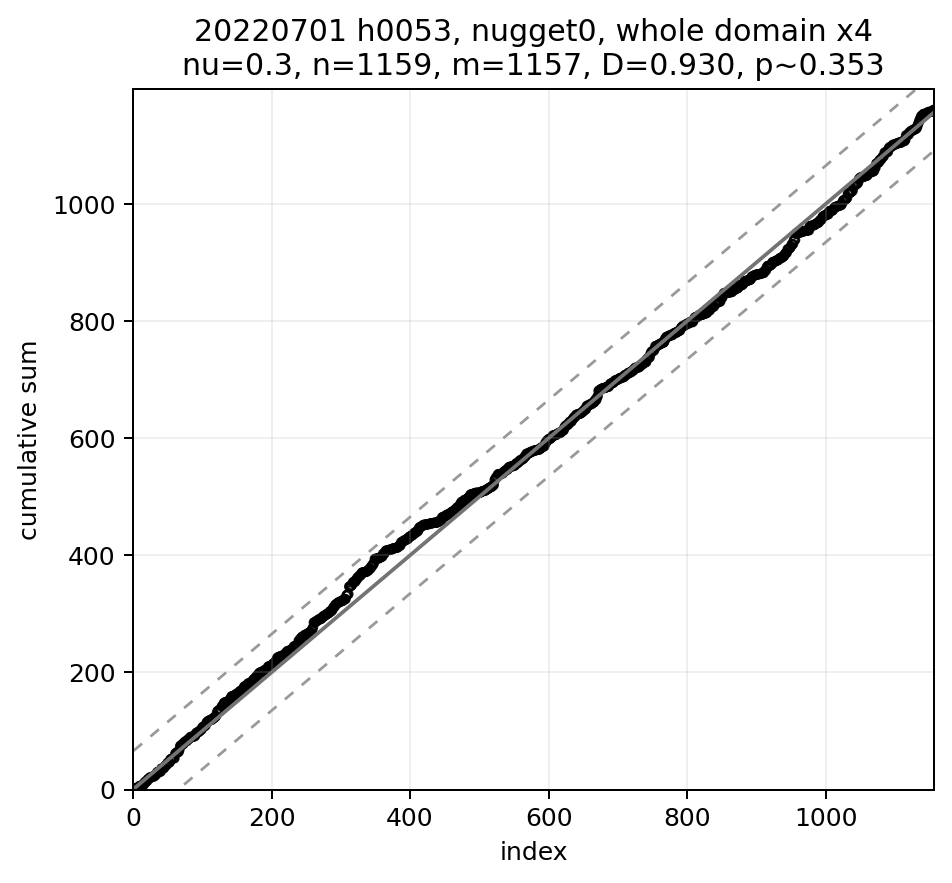

**outputs/day/local_eigen_analysis/eigdiag_sim_july2022_dgp_smooth0p5_fit_smooth_sweep_051926/nu0p5/20220701_h0053/nugget0_x4_eigdiag.png**

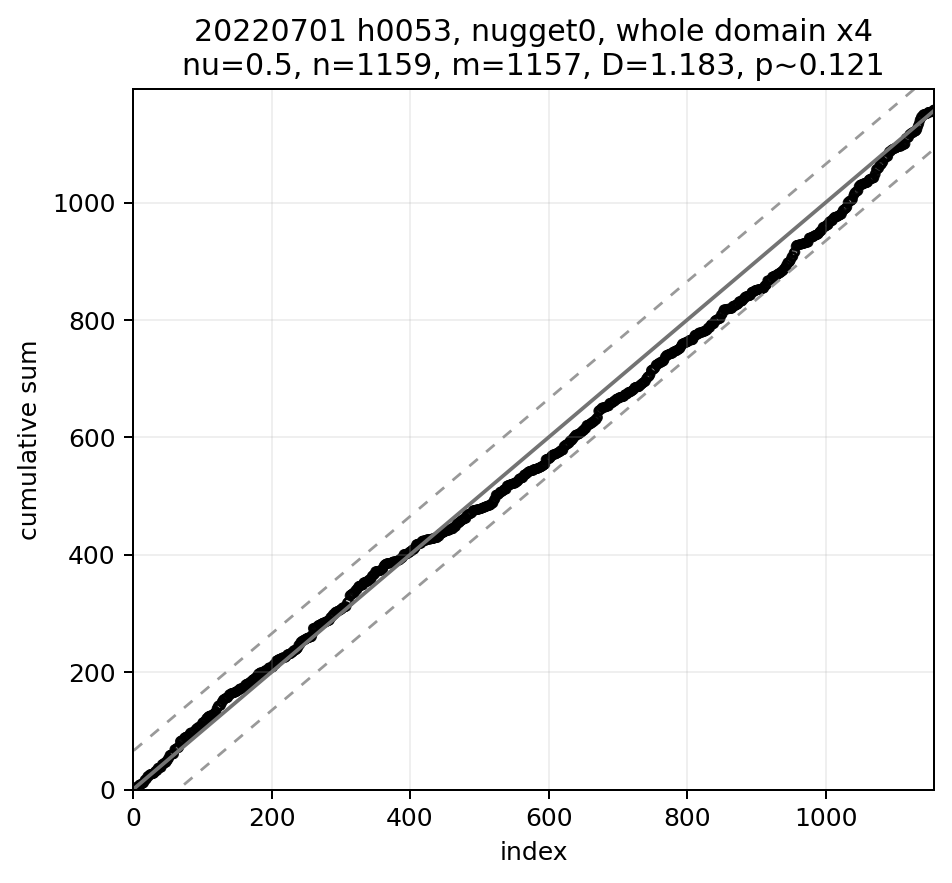

**outputs/day/local_eigen_analysis/eigdiag_sim_july2022_dgp_smooth0p5_fit_smooth_sweep_051926/nu1/20220701_h0053/nugget0_x4_eigdiag.png**

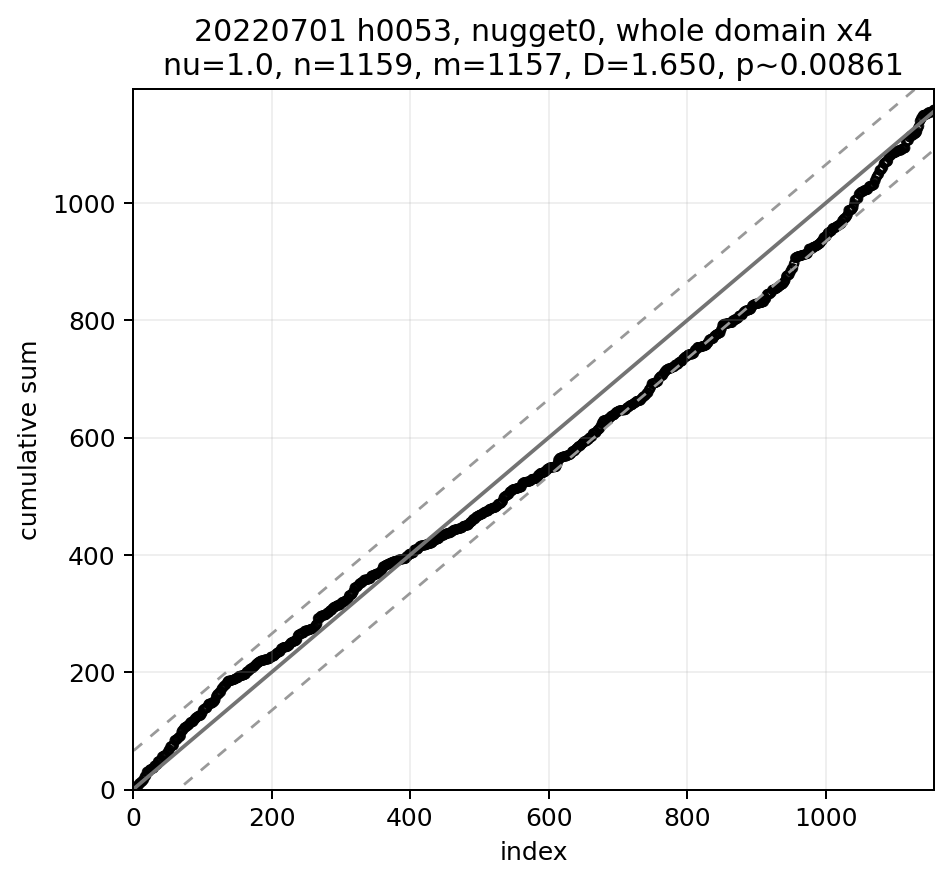

### sparse x8 (3 found)

**outputs/day/local_eigen_analysis/eigdiag_sim_july2022_dgp_smooth0p5_fit_smooth_sweep_051926/nu0p3/20220701_h0053/nugget0_x8_eigdiag.png**

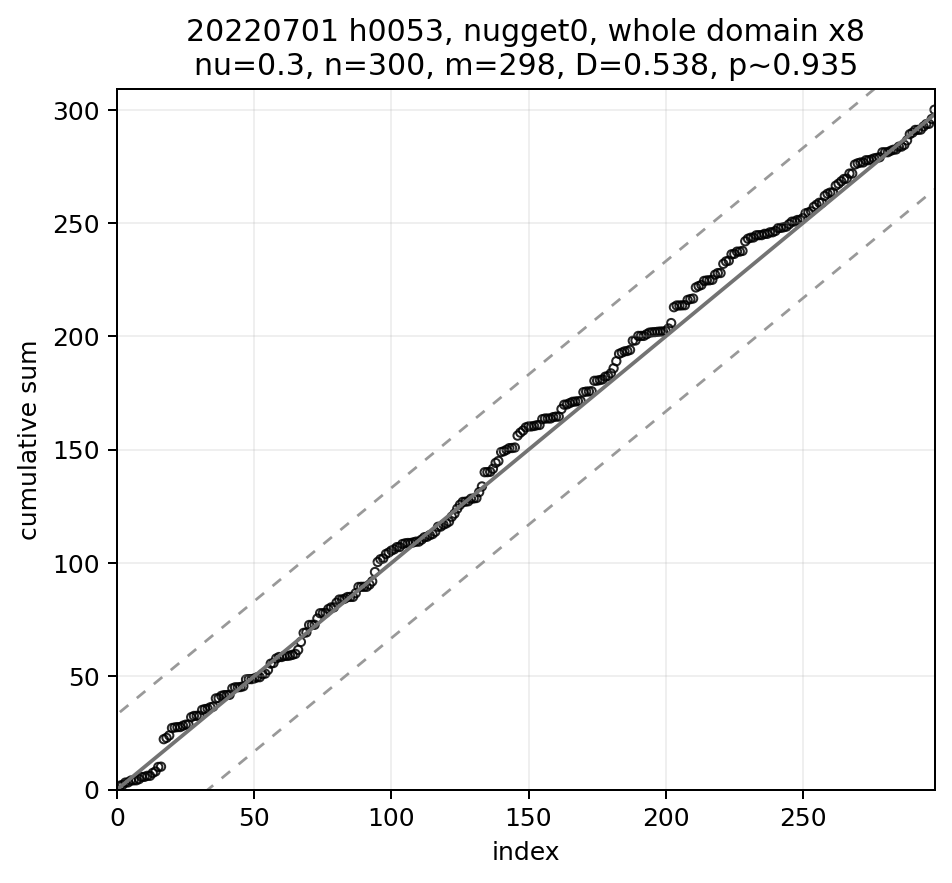

**outputs/day/local_eigen_analysis/eigdiag_sim_july2022_dgp_smooth0p5_fit_smooth_sweep_051926/nu0p5/20220701_h0053/nugget0_x8_eigdiag.png**

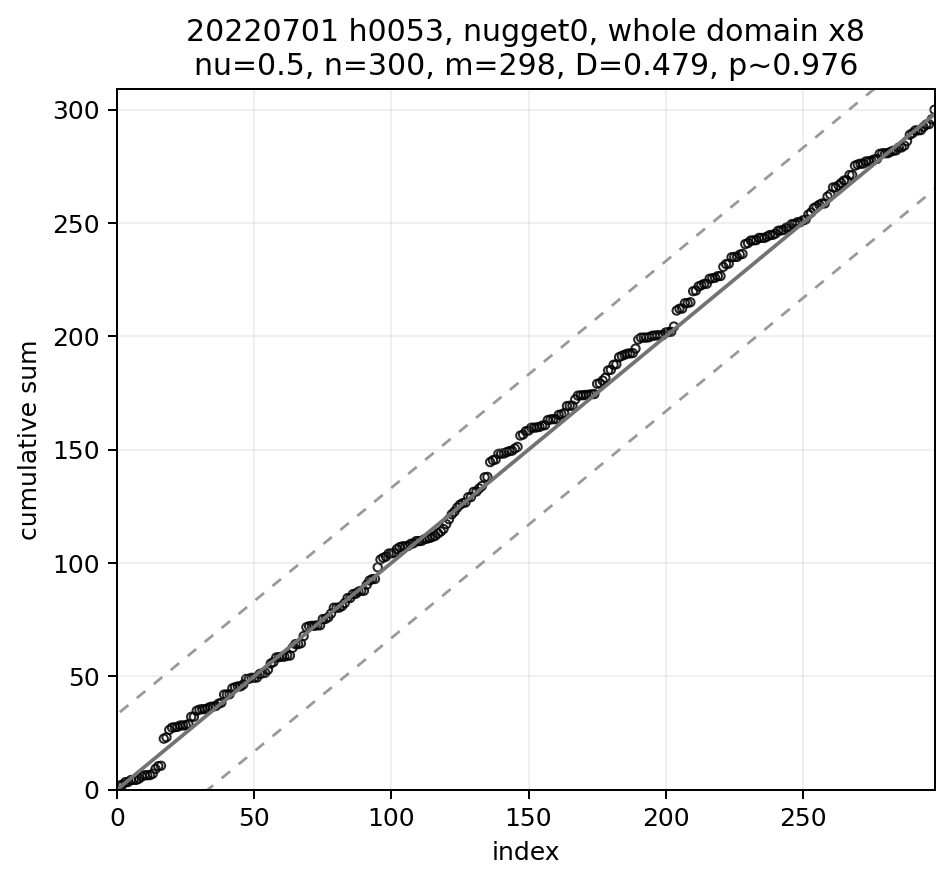

**outputs/day/local_eigen_analysis/eigdiag_sim_july2022_dgp_smooth0p5_fit_smooth_sweep_051926/nu1/20220701_h0053/nugget0_x8_eigdiag.png**

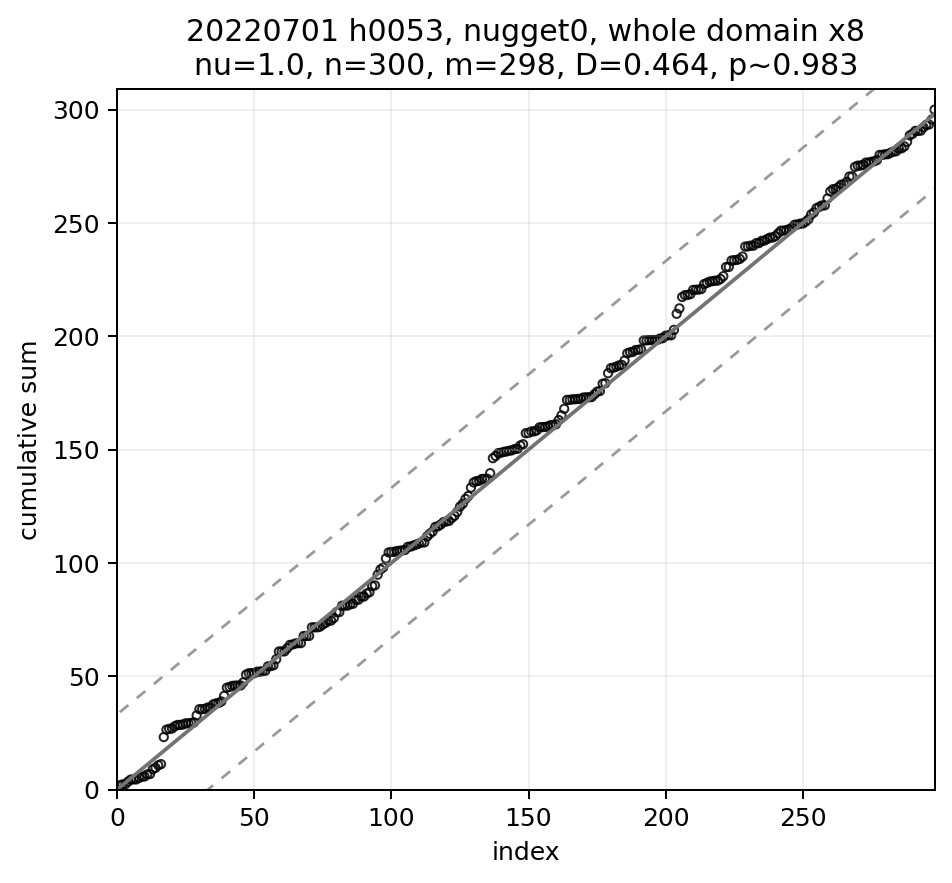

In [9]:
try:
    from IPython.display import Image, Markdown, display
except Exception:
    Image = None
    def Markdown(text):
        return text
    def display(obj):
        print(obj)


def _rel(path):
    path = Path(path)
    try:
        return path.relative_to(ROOT)
    except Exception:
        return path


def _display_png(path, width=1150):
    path = Path(path)
    display(Markdown(f"**{_rel(path)}**"))
    if Image is None:
        print(path)
    else:
        display(Image(filename=str(path), width=width))


def show_eigen_gallery(max_per_pattern=6):
    patterns = [
        ("tiles4x4 overview", "nu*/20*_h*/nugget0_tiles4x4_overview.png", 1250),
        ("sparse x4", "nu*/20*_h*/nugget0_x4_eigdiag.png", 760),
        ("sparse x8", "nu*/20*_h*/nugget0_x8_eigdiag.png", 760),
    ]
    any_found = False
    for label, pattern, width in patterns:
        matches = sorted(Path(OUT_ROOT).glob(pattern))
        display(Markdown(f"### {label} ({len(matches)} found)"))
        if not matches:
            print(f"No files matching: {OUT_ROOT / pattern}")
            continue
        any_found = True
        for path in matches[:max_per_pattern]:
            _display_png(path, width=width)
        if len(matches) > max_per_pattern:
            print(f"... {len(matches) - max_per_pattern} more files not shown")
    if not any_found:
        print("No eigen PNGs found yet. Run the fitting cell first, or check OUT_ROOT.")

show_eigen_gallery(max_per_pattern=9)
